In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import RidgeClassifier

plt.style.use('fivethirtyeight')
sns.set(font_scale=1.1)

# from google.colab import files

In [2]:
# upload heart.csv from your computer
# uploaded=files.upload()

df=pd.read_excel("encoded_dataset.xlsx")
df.head(10)

,Department,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate (bpm),Daily Steps,Academic Level,University,Systolic BP,Diastolic BP,Sleep Disorder
0,6,1,21,6,4,80,5,2,85,2,1,0,125,96,No Sleep Disorder
1,6,1,21,4,1,10,1,1,85,1,1,0,140,95,No Sleep Disorder
2,6,1,21,6,4,67,3,3,77,3,1,0,110,80,No Sleep Disorder
3,6,1,21,6,4,40,4,1,55,2,1,0,120,70,No Sleep Disorder
4,6,1,21,6,4,50,4,2,80,4,1,0,120,85,No Sleep Disorder
5,6,0,20,6,4,20,3,1,80,2,1,0,120,80,No Sleep Disorder
6,6,1,21,6,3,50,4,2,80,4,1,0,122,82,No Sleep Disorder
7,6,1,20,6,4,52,4,2,80,3,1,0,121,80,No Sleep Disorder
8,6,1,20,2,1,10,2,3,90,1,1,0,130,85,Sleep Apnea
9,6,1,21,2,2,30,4,2,80,2,1,0,122,80,Insomnia


In [3]:
df.shape

(1732, 15)

In [4]:
df

,Department,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate (bpm),Daily Steps,Academic Level,University,Systolic BP,Diastolic BP,Sleep Disorder
0,6,1,21,6,4,80,5,2,85,2,1,0,125,96,No Sleep Disorder
1,6,1,21,4,1,10,1,1,85,1,1,0,140,95,No Sleep Disorder
2,6,1,21,6,4,67,3,3,77,3,1,0,110,80,No Sleep Disorder
3,6,1,21,6,4,40,4,1,55,2,1,0,120,70,No Sleep Disorder
4,6,1,21,6,4,50,4,2,80,4,1,0,120,85,No Sleep Disorder
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1727,12,1,25,4,3,47,3,2,80,4,4,6,122,80,No Sleep Disorder
1728,12,1,26,2,1,17,1,2,90,1,4,6,144,95,Insomnia
1729,12,1,26,4,3,52,3,2,76,4,4,6,123,90,No Sleep Disorder
1730,19,1,25,4,2,67,3,2,68,1,4,6,120,66,No Sleep Disorder


# Outliers remove

In [5]:
from scipy.stats import zscore
import numpy as np

z = np.abs(zscore(df.select_dtypes(include=np.number)))

df = df[(z < 3).all(axis=1)]

print(df.shape)

(1674, 15)


In [6]:
df.isnull().sum()

Department                 0
Gender                     0
Age                        0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Heart Rate (bpm)           0
Daily Steps                0
Academic Level             0
University                 0
Systolic BP                0
Diastolic BP               0
Sleep Disorder             0
dtype: int64

In [7]:
# Define Target and Feature Types
y=df["Sleep Disorder"]
X=df.drop("Sleep Disorder",axis=1)

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [9]:
unique_values, counts = np.unique(y, return_counts=True)

# ফলাফল দেখার জন্য ডিকশনারি আকারে প্রিন্ট করা
print(dict(zip(unique_values, counts)))

{np.int64(0): np.int64(243), np.int64(1): np.int64(1183), np.int64(2): np.int64(248)}


In [10]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, shuffle=True)

In [11]:
from sklearn.preprocessing import StandardScaler

# ৩. StandardScaler অ্যাপ্লাই করা
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)

# ৪. স্কেল করা ডেটা দিয়ে পুনরায় ডাটাফ্রেম তৈরি করা
# এখানে index=X.index যুক্ত করা হয়েছে, যাতে X এবং y এর সারিগুলো ঠিকভাবে মিলে যায়!
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns, index=X.index)

# স্কেল করা ডেটার প্রথম ৫টি সারি দেখা
X_scaled.head()

,Department,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate (bpm),Daily Steps,Academic Level,University,Systolic BP,Diastolic BP
0,-0.832248,0.59713,-0.596425,1.224487,1.335568,1.391802,1.500662,-0.381950,0.542394,-0.390762,-1.053544,-1.544901,0.201393,1.762457
1,-0.832248,0.59713,-0.596425,0.043732,-1.173681,-1.210498,-1.702536,-1.579297,0.542394,-1.289298,-1.053544,-1.544901,1.747398,1.652595
2,-0.832248,0.59713,-0.596425,1.224487,1.335568,0.908518,-0.100937,0.815398,-0.147158,0.507775,-1.053544,-1.544901,-1.344612,0.004660
3,-0.832248,0.59713,-0.596425,1.224487,1.335568,-0.095227,0.699862,-1.579297,-2.043427,-0.390762,-1.053544,-1.544901,-0.313942,-1.093964
4,-0.832248,0.59713,-0.596425,1.224487,1.335568,0.276530,0.699862,-0.381950,0.111424,1.406312,-1.053544,-1.544901,-0.313942,0.553971


In [12]:
from sklearn.model_selection import train_test_split

# X_scaled এবং y কে 80% Train এবং 20% Test ডেটায় স্প্লিট করা
# test_size=0.2 মানে হলো ২০% ডেটা টেস্টিংয়ের জন্য রাখা হবে
# random_state=42 দেওয়া হয়েছে যাতে যতবারই রান করুন না কেন, স্প্লিট একই থাকে
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# স্প্লিট ঠিকমতো হলো কি না তা চেক করার জন্য ডেটার আকার (shape) দেখা
print("Total rows in dataset:", X_scaled.shape[0])
print("---------------------------------------")
print("X_train shape (80%):", X_train.shape)
print("X_test shape  (20%):", X_test.shape)
print("y_train shape (80%):", y_train.shape)
print("y_test shape  (20%):", y_test.shape)

Total rows in dataset: 1674
---------------------------------------
X_train shape (80%): (1339, 14)
X_test shape  (20%): (335, 14)
y_train shape (80%): (1339,)
y_test shape  (20%): (335,)


C:\Users\skmah\AppData\Local\Temp\ipykernel_17020\3547943242.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


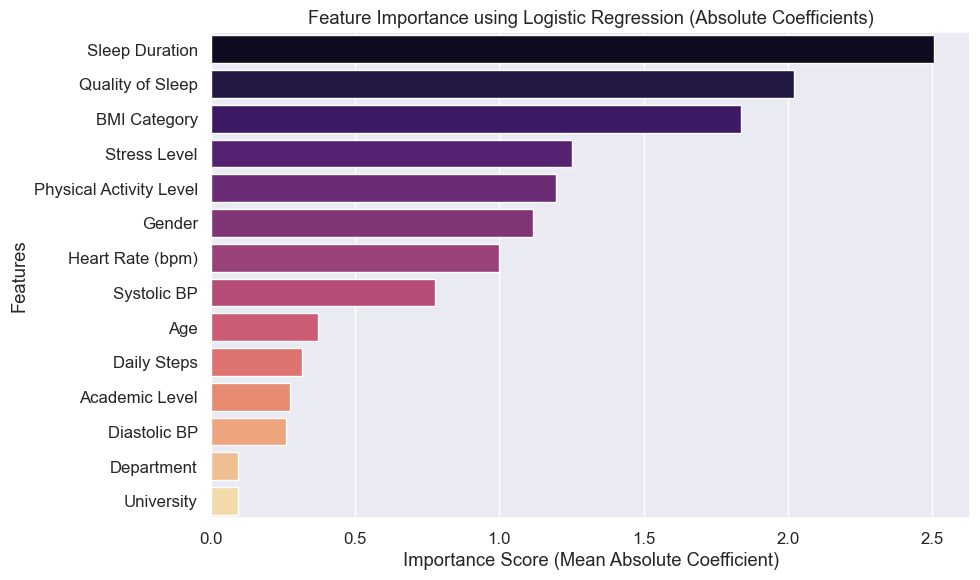

                    Feature  Importance
3            Sleep Duration    2.508068
4          Quality of Sleep    2.022284
7              BMI Category    1.837344
6              Stress Level    1.252408
5   Physical Activity Level    1.195772
1                    Gender    1.116945
8          Heart Rate (bpm)    0.997957
12              Systolic BP    0.776629
2                       Age    0.372656
9               Daily Steps    0.314858
10           Academic Level    0.273782
13             Diastolic BP    0.260645
0                Department    0.092945
11               University    0.092158


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ১. ডেটা স্কেলিং করা (লজিস্টিক রিগ্রেশনের কোএফিসিয়েন্ট সঠিকভাবে তুলনা করার জন্য এটি বাধ্যতামূলক)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# (যদি X_test থাকে, তাহলে X_test_scaled = scaler.transform(X_test) করবেন)

# ২. লজিস্টিক রিগ্রেশন মডেল তৈরি এবং ট্রেইন করা
# max_iter বাড়িয়ে দেওয়া হয়েছে যাতে মডেলটি ভালোভাবে converge করতে পারে
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_scaled, y_train)

# ৩. Feature Importance বা Coefficients বের করা
# যেহেতু আপনার টার্গেটে ৩টি ক্লাস (0, 1, 2) থাকতে পারে (Multiclass),
# তাই আমরা সব ক্লাসের অ্যাবসলিউট (absolute) কোএফিসিয়েন্টগুলোর গড় নিচ্ছি।
importances = np.mean(np.abs(log_model.coef_), axis=0)

# ৪. ডাটাফ্রেম তৈরি করা এবং বড় থেকে ছোট ক্রমানুসারে সাজানো
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# ৫. ভিজ্যুয়ালাইজেশন (বার প্লট)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Feature Importance using Logistic Regression (Absolute Coefficients)')
plt.xlabel('Importance Score (Mean Absolute Coefficient)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# ভ্যালুগুলো প্রিন্ট করে দেখতে চাইলে:
print(feature_importance_df)

In [14]:
! pip install catboost

In [15]:
import numpy as np
import pandas as pd

# ক্লাসিফিকেশন মডেল ইমপোর্ট
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# ক্লাসিফিকেশন ও রিগ্রেশন মেট্রিক্স ইমপোর্ট
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             mean_absolute_error, mean_squared_error, r2_score)

# ১. মডেলগুলোর একটি ডিকশনারি তৈরি করা
models = {
    "Logistic Regression": LogisticRegression(max_iter=7, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "KNN": KNeighborsClassifier(),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
}

# ২. রেজাল্ট সেভ করার জন্য একটি খালি লিস্ট
results = []

print("মডেলগুলোর ট্রেইনিং শুরু হয়েছে, অনুগ্রহ করে অপেক্ষা করুন...\n")

# ৩. লুপ চালিয়ে প্রতিটি মডেল ট্রেইন ও টেস্ট করা
for name, model in models.items():
    try:
        # মডেল ট্রেইন করা
        model.fit(X_train, y_train)

        # টেস্ট ডেটা দিয়ে প্রেডিকশন করা
        y_pred = model.predict(X_test)

        # ---- ক্লাসিফিকেশন মেট্রিক্স ----
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        # ---- রিগ্রেশন মেট্রিক্স ----
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse) # MSE কে রুট করলেই RMSE পাওয়া যায়
        r2 = r2_score(y_test, y_pred)

        # রেজাল্ট লিস্টে সেভ করে রাখা
        results.append({
            "Model": name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R2 Score": r2
        })

    except Exception as e:
        print(f"Error in {name}: {e}")

# ৪. রেজাল্টগুলো ডাটাফ্রেমে রূপান্তর করা
results_df = pd.DataFrame(results)

# এক্যুরেসি অনুযায়ী বড় থেকে ছোট আকারে সাজানো
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

# ৫. ফাইনাল রেজাল্ট প্রিন্ট করা
print("============= Detailed Model Performance Metrics =============")
display(results_df) # জুপিটার নোটবুকে সুন্দরভাবে দেখার জন্য print এর বদলে display ব্যবহার করতে পারেন

মডেলগুলোর ট্রেইনিং শুরু হয়েছে, অনুগ্রহ করে অপেক্ষা করুন...



c:\Users\skmah\.conda\envs\gpu_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 7 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=7).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


============= Detailed Model Performance Metrics =============


,Model,Accuracy,Precision,Recall,F1 Score,MAE,MSE,RMSE,R2 Score
0,SVM,0.979104,0.979129,0.979104,0.978634,0.026866,0.038806,0.196992,0.869938
1,CatBoost,0.976119,0.976164,0.976119,0.975455,0.029851,0.041791,0.204429,0.859933
2,Logistic Regression,0.973134,0.973732,0.973134,0.973292,0.041791,0.071642,0.267660,0.759885
3,XGBoost,0.967164,0.966778,0.967164,0.966066,0.041791,0.059701,0.244339,0.799904
4,Random Forest,0.964179,0.965619,0.964179,0.961988,0.041791,0.053731,0.231800,0.819914
5,Gradient Boosting,0.961194,0.961629,0.961194,0.959048,0.044776,0.056716,0.238152,0.809909
6,Decision Tree,0.958209,0.957250,0.958209,0.957433,0.047761,0.059701,0.244339,0.799904
7,KNN,0.937313,0.934640,0.937313,0.933847,0.080597,0.116418,0.341201,0.609814
8,AdaBoost,0.886567,0.897360,0.886567,0.885348,0.202985,0.382090,0.618134,-0.280612


C:\Users\skmah\AppData\Local\Temp\ipykernel_17020\1599803069.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


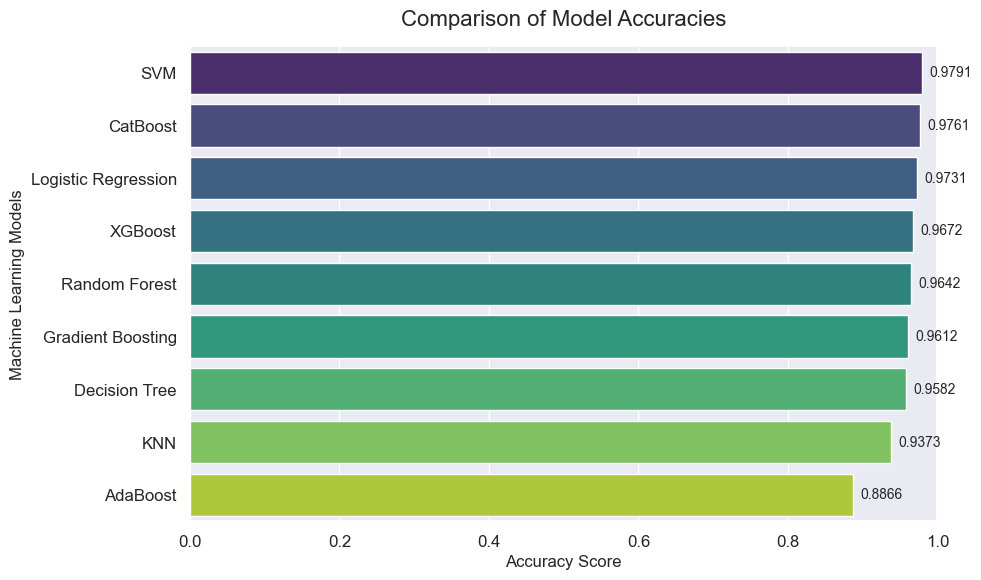

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# ১. গ্রাফের সাইজ নির্ধারণ করা
plt.figure(figsize=(10, 6))

# ২. Seaborn দিয়ে একটি সুন্দর Bar Plot তৈরি করা
# palette='viridis' একটি সুন্দর কালার থিম যুক্ত করবে
sns.barplot(
    x='Accuracy',
    y='Model',
    data=results_df,
    palette='viridis'
)

# ৩. টাইটেল এবং লেবেল যোগ করা
plt.title('Comparison of Model Accuracies', fontsize=16, pad=15)
plt.xlabel('Accuracy Score', fontsize=12)
plt.ylabel('Machine Learning Models', fontsize=12)

# ৪. X-অক্ষকে ০ থেকে ১.০ (অর্থাৎ ০-১০০%) এর মধ্যে সীমাবদ্ধ রাখা
# যাতে সবগুলো মডেলের তুলনা ভালোভাবে বোঝা যায়
plt.xlim(0, 1.0)

# বারগুলোর শেষে অ্যাক্যুরেসির মান (Value) লিখে দেওয়ার জন্য একটি লুপ
for index, value in enumerate(results_df['Accuracy']):
    plt.text(value + 0.01, index, f'{value:.4f}', va='center', fontsize=10)

# ৫. গ্রাফটি প্রদর্শন করা
plt.tight_layout()
plt.show()

# Bayesian optimization

In [17]:
! pip install scikit-optimize

In [18]:
# প্রথমে scikit-optimize ইনস্টল করা না থাকলে নিচের লাইনটির কমেন্ট (#) তুলে একবার রান করে নিন
# !pip install scikit-optimize xgboost catboost

import pandas as pd
import numpy as np
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

# নতুন মেট্রিক্সগুলো ইমপোর্ট করা হলো
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             mean_absolute_error, mean_squared_error, r2_score)

# ১. মডেল এবং তাদের হাইপারপ্যারামিটার স্পেস (Search Space) ডিফাইন করা
# (মডেলগুলো আগে থেকেই ইমপোর্ট করা আছে ধরে নেওয়া হলো)
models_params = {
    "Logistic Regression": (
        LogisticRegression(max_iter=7, random_state=42),
        {'C': Real(1e-4, 1e+4, prior='log-uniform')}
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        {'max_depth': Integer(1, 50), 'min_samples_split': Integer(2, 10)}
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {'n_estimators': Integer(10, 200), 'max_depth': Integer(1, 50)}
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=42),
        {'n_estimators': Integer(10, 200), 'learning_rate': Real(0.01, 0.5, prior='log-uniform')}
    ),
    "SVM": (
        SVC(random_state=42),
        {'C': Real(1, 5, prior='log-uniform'), 'gamma': Real(1e-3, 1e+1, prior='log-uniform')}
    ),
    "KNN": (
        KNeighborsClassifier(),
        {'n_neighbors': Integer(1, 20)}
    ),
    "AdaBoost": (
        AdaBoostClassifier(random_state=42),
        {'n_estimators': Integer(10, 200), 'learning_rate': Real(0.01, 1.0, prior='log-uniform')}
    ),
    "XGBoost": (
        XGBClassifier(eval_metric='mlogloss', random_state=42),
        {'n_estimators': Integer(10, 200), 'max_depth': Integer(1, 20), 'learning_rate': Real(0.01, 0.5, prior='log-uniform')}
    ),
    "CatBoost": (
        CatBoostClassifier(verbose=0, random_state=42),
        {'iterations': Integer(10, 200), 'depth': Integer(1, 10), 'learning_rate': Real(0.01, 0.5, prior='log-uniform')}
    )
}

results = []
best_params_list = []

print("Bayesian Optimization শুরু হয়েছে। ৯টি মডেল অপটিমাইজ হতে কিছুটা সময় নিতে পারে...\n")

# ২. লুপ চালিয়ে প্রতিটি মডেল অপটিমাইজ করা
for name, (model, params) in models_params.items():
    print(f"Optimizing {name}...")
    try:
        # BayesSearchCV সেটআপ (n_iter=10 এবং cv=3)
        opt = BayesSearchCV(
            estimator=model,
            search_spaces=params,
            n_iter=10,
            cv=3,
            n_jobs=-1, # পিসির সব কোর ব্যবহার করবে
            random_state=42
        )

        # ট্রেইন ডেটায় অপটিমাইজেশন রান করা
        opt.fit(X_train, y_train)

        # বেস্ট প্যারামিটার এবং CV স্কোর
        best_params = opt.best_params_
        best_cv_score = opt.best_score_

        # -----------------------------------------------------------------
        # সেরা মডেলটি দিয়ে টেস্ট ডেটায় (X_test) প্রেডিকশন করে নতুন মেট্রিক্স বের করা
        # -----------------------------------------------------------------
        y_pred = opt.predict(X_test)

        # ক্লাসিফিকেশন মেট্রিক্স
        test_accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        # রিগ্রেশন মেট্রিক্স (যদিও ক্লাসিফিকেশন মডেলে এগুলো খুব একটা অর্থবহ নয়)
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)

        # রেজাল্ট লিস্টে সেভ করা
        results.append({
            "Model": name,
            "CV Accuracy (Train)": best_cv_score,
            "Test Accuracy": test_accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R2 Score": r2
        })

        best_params_list.append({
            "Model": name,
            "Optimized Parameters": str(dict(best_params))
        })

    except Exception as e:
        print(f"Error in {name}: {e}")

# ৩. রেজাল্টগুলো ডাটাফ্রেমে (Table) রূপান্তর
df_results = pd.DataFrame(results)
df_params = pd.DataFrame(best_params_list)

# Test Accuracy অনুযায়ী বড় থেকে ছোট আকারে সাজানো
df_results = df_results.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)

# ৪. টেবিলগুলো সুন্দর করে প্রিন্ট করা
print("\n============= Detailed Performance Metrics (Optimized Models) =============")
display(df_results) # জুপিটার নোটবুকে display() ব্যবহার করলে টেবিল সুন্দর দেখায়

print("\n============= Optimized Parameters Table =============")
pd.set_option('display.max_colwidth', None)
display(df_params)

Bayesian Optimization শুরু হয়েছে। ৯টি মডেল অপটিমাইজ হতে কিছুটা সময় নিতে পারে...

Optimizing Logistic Regression...


c:\Users\skmah\.conda\envs\gpu_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 7 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=7).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Optimizing Decision Tree...
Optimizing Random Forest...
Optimizing Gradient Boosting...
Optimizing SVM...
Optimizing KNN...
Optimizing AdaBoost...
Optimizing XGBoost...
Optimizing CatBoost...

============= Detailed Performance Metrics (Optimized Models) =============


,Model,CV Accuracy (Train),Test Accuracy,Precision,Recall,F1 Score,MAE,MSE,RMSE,R2 Score
0,SVM,0.967147,0.979104,0.979027,0.979104,0.979037,0.029851,0.047761,0.218543,0.839924
1,CatBoost,0.958183,0.976119,0.976117,0.976119,0.975445,0.032836,0.050746,0.225269,0.829919
2,Logistic Regression,0.953712,0.970149,0.970459,0.970149,0.969939,0.044776,0.074627,0.273179,0.749881
3,Random Forest,0.952209,0.964179,0.965619,0.964179,0.961988,0.041791,0.053731,0.231800,0.819914
4,Decision Tree,0.935031,0.961194,0.960667,0.961194,0.960230,0.044776,0.056716,0.238152,0.809909
5,XGBoost,0.955192,0.961194,0.960241,0.961194,0.960269,0.050746,0.074627,0.273179,0.749881
6,Gradient Boosting,0.952206,0.958209,0.960166,0.958209,0.955142,0.050746,0.068657,0.262024,0.769890
7,AdaBoost,0.885747,0.958209,0.961475,0.958209,0.959033,0.056716,0.086567,0.294223,0.709861
8,KNN,0.939515,0.934328,0.932801,0.934328,0.933241,0.086567,0.128358,0.358271,0.569795



============= Optimized Parameters Table =============


,Model,Optimized Parameters
0,Logistic Regression,{'C': 0.3619595990038508}
1,Decision Tree,"{'max_depth': 41, 'min_samples_split': 3}"
2,Random Forest,"{'max_depth': 40, 'n_estimators': 93}"
3,Gradient Boosting,"{'learning_rate': 0.04974556006241094, 'n_estimators': 148}"
4,SVM,"{'C': 3.6969231905107693, 'gamma': 0.004869521028037488}"
5,KNN,{'n_neighbors': 1}
6,AdaBoost,"{'learning_rate': 0.3972893133963027, 'n_estimators': 93}"
7,XGBoost,"{'learning_rate': 0.4200765500185469, 'max_depth': 14, 'n_estimators': 176}"
8,CatBoost,"{'depth': 6, 'iterations': 185, 'learning_rate': 0.0697400151786318}"


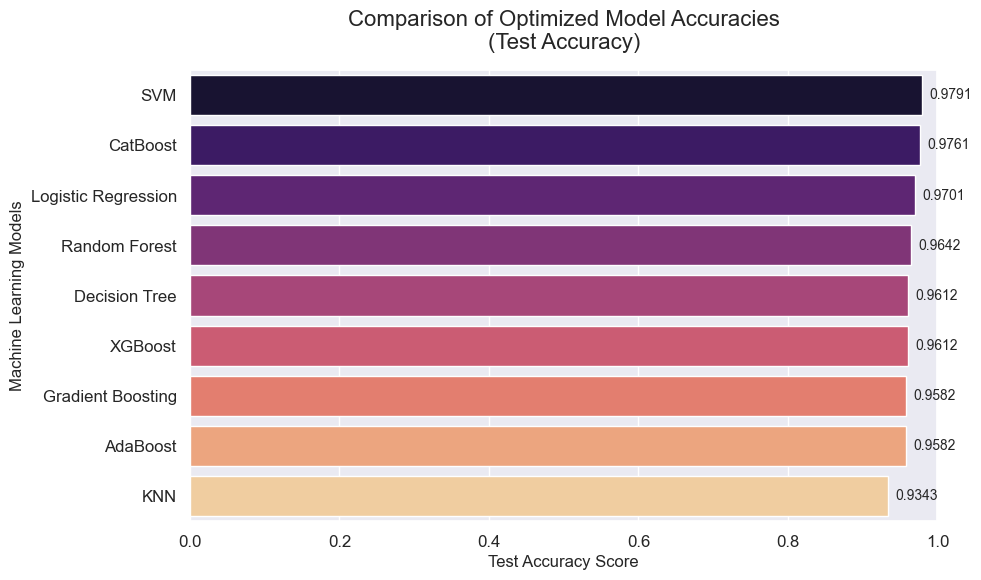

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# ১. গ্রাফের জন্য ডেটা Test Accuracy অনুযায়ী বড় থেকে ছোট আকারে সাজিয়ে নেওয়া
df_results_sorted = df_results.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)

# ২. গ্রাফের সাইজ নির্ধারণ করা
plt.figure(figsize=(10, 6))

# ৩. Seaborn দিয়ে একটি সুন্দর Bar Plot তৈরি করা
# Warning এড়ানোর জন্য hue='Model' এবং legend=False যোগ করা হয়েছে
sns.barplot(
    x='Test Accuracy',
    y='Model',
    data=df_results_sorted,
    palette='magma',
    hue='Model',
    legend=False
)

# ৪. টাইটেল এবং লেবেল যোগ করা
plt.title('Comparison of Optimized Model Accuracies\n(Test Accuracy)', fontsize=16, pad=15)
plt.xlabel('Test Accuracy Score', fontsize=12)
plt.ylabel('Machine Learning Models', fontsize=12)

# ৫. X-অক্ষকে ০ থেকে ১.০ (অর্থাৎ ০-১০০%) এর মধ্যে সীমাবদ্ধ রাখা
plt.xlim(0, 1.0)

# ৬. বারগুলোর ডানপাশে অপটিমাইজড অ্যাক্যুরেসির মান (Value) লিখে দেওয়ার জন্য একটি লুপ
for index, value in enumerate(df_results_sorted['Test Accuracy']):
    plt.text(value + 0.01, index, f'{value:.4f}', va='center', fontsize=10)

# ৭. গ্রাফটি প্রদর্শন করা
plt.tight_layout()
plt.show()

In [20]:
import ast
import numpy as np
import pandas as pd
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             mean_absolute_error, mean_squared_error, r2_score)

# ১. অপটিমাইজেশন রেজাল্ট থেকে সেরা ৩টি মডেল নির্বাচন করা
top_n = 3
top_models_names = df_results.head(top_n)['Model'].tolist()
print(f"Stacking এর জন্য নির্বাচিত সেরা {top_n}টি মডেল: {top_models_names}\n")

estimators = []

# ২. লুপ চালিয়ে সেরা ৩টি মডেলের প্যারামিটার সেট করা
for name in top_models_names:
    # যদি মডেলটি SVM হয়, তাহলে আপনার নির্দিষ্ট করা প্যারামিটার সেট হবে
    if name == "SVM": 
        custom_svm_params = {
            'C': 50.83471137062506,
            'gamma': 0.004869521028037488,
            'kernel': 'rbf',         # gamma সাধারণত rbf কার্নেলের সাথে ব্যবহৃত হয়
            'probability': True,     # Stacking এর জন্য True রাখা ভালো
            'random_state': 42
        }
        base_model = models_params[name][0].set_params(**custom_svm_params)
        print("SVM এর জন্য আপনার নির্দিষ্ট করা C এবং gamma প্যারামিটার সেট করা হয়েছে।")
        
    # অন্য মডেলগুলোর জন্য আগের মতোই ডাটাফ্রেম থেকে অপটিমাইজড প্যারামিটার নিবে
    else:
        # প্যারামিটার স্ট্রিং থেকে ডিকশনারিতে রূপান্তর
        params_str = df_params[df_params['Model'] == name]['Optimized Parameters'].values[0]
        params_dict = ast.literal_eval(params_str)
        
        # বেস মডেল তৈরি করে অপটিমাইজড প্যারামিটার অ্যাপ্লাই করা
        base_model = models_params[name][0].set_params(**params_dict)

    # স্ট্যাকিংয়ের জন্য estimators লিস্টে যুক্ত করা
    estimators.append((name, base_model))

# ৩. Stacking Classifier ডিফাইন করা
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=RidgeClassifier(random_state=42),
    cv=5, # ইন্টার্নাল ক্রস-ভ্যালিডেশন
    n_jobs=-1
)

print("Main Dataset-এর ওপর Stacking Classifier ট্রেইনিং হচ্ছে, অনুগ্রহ করে অপেক্ষা করুন...\n")

# ৪. মেইন ডেটাসেটের ট্রেইন ডেটায় স্ট্যাকিং মডেলটি ট্রেইন করা
stacking_clf.fit(X_train, y_train)

# ৫. টেস্ট ডেটায় প্রেডিকশন করা
y_pred_stack = stacking_clf.predict(X_test)

# ৬. পারফরম্যান্স মেট্রিক্স ক্যালকুলেট করা (সবগুলো মেট্রিক্স)
stack_acc = accuracy_score(y_test, y_pred_stack)
stack_prec = precision_score(y_test, y_pred_stack, average='weighted', zero_division=0)
stack_rec = recall_score(y_test, y_pred_stack, average='weighted', zero_division=0)
stack_f1 = f1_score(y_test, y_pred_stack, average='weighted', zero_division=0)

stack_mae = mean_absolute_error(y_test, y_pred_stack)
stack_mse = mean_squared_error(y_test, y_pred_stack)
stack_rmse = np.sqrt(stack_mse)
stack_r2 = r2_score(y_test, y_pred_stack)

# ৭. রেজাল্ট ডাটাফ্রেমে সাজানো
stacking_results = pd.DataFrame([{
    "Model": "Stacked Ensemble (Top 3)",
    "CV Accuracy (Train)": "-", # Stacking এর জন্য এখানে ড্যাশ দেওয়া হলো
    "Test Accuracy": stack_acc,
    "Precision": stack_prec,
    "Recall": stack_rec,
    "F1 Score": stack_f1,
    "MAE": stack_mae,
    "MSE": stack_mse,
    "RMSE": stack_rmse,
    "R2 Score": stack_r2
}])

# ৮. আগের সব মডেলের রেজাল্ট (df_results) এর সাথে Stacking এর রেজাল্ট যুক্ত করা
final_combined_results = pd.concat([df_results, stacking_results], ignore_index=True)

# ৯. Test Accuracy অনুযায়ী বড় থেকে ছোট আকারে সাজানো (যাতে বেস্ট মডেলটি উপরে থাকে)
final_combined_results = final_combined_results.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)

# ১০. ফাইনাল রেজাল্ট প্রিন্ট করা
print("============= All Models vs Stacking Performance =============")
display(final_combined_results)

Stacking এর জন্য নির্বাচিত সেরা 3টি মডেল: ['SVM', 'CatBoost', 'Logistic Regression']

SVM এর জন্য আপনার নির্দিষ্ট করা C এবং gamma প্যারামিটার সেট করা হয়েছে।
Main Dataset-এর ওপর Stacking Classifier ট্রেইনিং হচ্ছে, অনুগ্রহ করে অপেক্ষা করুন...

============= All Models vs Stacking Performance =============


,Model,CV Accuracy (Train),Test Accuracy,Precision,Recall,F1 Score,MAE,MSE,RMSE,R2 Score
0,Stacked Ensemble (Top 3),-,0.988060,0.988978,0.988060,0.988247,0.011940,0.011940,0.109272,0.959981
1,SVM,0.967147,0.979104,0.979027,0.979104,0.979037,0.029851,0.047761,0.218543,0.839924
2,CatBoost,0.958183,0.976119,0.976117,0.976119,0.975445,0.032836,0.050746,0.225269,0.829919
3,Logistic Regression,0.953712,0.970149,0.970459,0.970149,0.969939,0.044776,0.074627,0.273179,0.749881
4,Random Forest,0.952209,0.964179,0.965619,0.964179,0.961988,0.041791,0.053731,0.231800,0.819914
5,Decision Tree,0.935031,0.961194,0.960667,0.961194,0.960230,0.044776,0.056716,0.238152,0.809909
6,XGBoost,0.955192,0.961194,0.960241,0.961194,0.960269,0.050746,0.074627,0.273179,0.749881
7,Gradient Boosting,0.952206,0.958209,0.960166,0.958209,0.955142,0.050746,0.068657,0.262024,0.769890
8,AdaBoost,0.885747,0.958209,0.961475,0.958209,0.959033,0.056716,0.086567,0.294223,0.709861
9,KNN,0.939515,0.934328,0.932801,0.934328,0.933241,0.086567,0.128358,0.358271,0.569795


In [21]:
# import pickle
# filename= 'model.pkl'

# with open(filename, 'wb') as file:
#     pickle.dump(stacking_clf, file)

In [22]:
# with open('model.pkl', 'rb') as file:
#     ok=pickle.load(file)

In [23]:
# import pickle

# # Scaler সেভ করো (যেটা তুমি ট্রেনিংয়ে ব্যবহার করেছ)
# with open('scaler.pkl', 'wb') as file:
#     pickle.dump(scaler, file) # ধরছি তোমার scaler অবজেক্টের নাম 'scaler'

# # LabelEncoder গুলো সেভ করো (Department, Gender, University এর জন্য)
# # অথবা ম্যানুয়ালি ম্যাপ করতে পারো নিচের Gradio কোডের মতো।

In [27]:
import pickle

# মডেল সেভ করা
with open('model.pkl', 'wb') as file:
    pickle.dump(models['SVM'], file)

# স্কেলার সেভ করা (এটি খুবই জরুরি!)
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

In [37]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score

# মডেলগুলো
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# ১. ডেটা লোড
df = pd.read_excel('dataset before encoding.xlsx')

# ২. প্রিপ্রসেসিং
def preprocess_data(df):
    if 'Blood Pressure' in df.columns:
        df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(float)
        df.drop('Blood Pressure', axis=1, inplace=True)
    if 'Daily Steps' in df.columns:
        df['Daily Steps'] = df['Daily Steps'].astype(str).str.extract(r'(\d+)')[0].fillna(0).astype(float)
    if 'Sleep Duration' in df.columns:
        df['Sleep Duration'] = df['Sleep Duration'].astype(str).str.extract(r'(\d+)')[0].fillna(0).astype(float)
    return df

df = preprocess_data(df)

# ৩. এনকোডিং
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

X = df.drop('Sleep Disorder', axis=1)
y = df['Sleep Disorder']

# ৪. Split & Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ৫. সব মডেলের ডিকশনারি
all_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
}

# ৬. Stacking Model যোগ করা
estimators = [('svm', SVC(probability=True)), ('cat', CatBoostClassifier(verbose=0)), ('lr', LogisticRegression())]
all_models["Stacking"] = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())

# ৭. সেরা মডেল খুঁজে বের করা
best_acc = 0
best_model = None
best_model_name = ""

print("--- মডেল পারফরম্যান্স চেক হচ্ছে ---")
for name, model in all_models.items():
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    print(f"{name}: {acc:.4f}")
    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_model_name = name

print(f"\n🏆 সেরা মডেল: {best_model_name} (Accuracy: {best_acc:.4f})")

# ৮. সেরা মডেল সেভ করা
saved_data = {
    'model': best_model,
    'scaler': scaler,
    'label_encoders': label_encoders,
    'feature_names': X.columns.tolist()
}
joblib.dump(saved_data, 'best_sleep_model.pkl')
print(f"✅ সফলভাবে '{best_model_name}' সেভ করা হয়েছে!")

C:\Users\skmah\AppData\Local\Temp\ipykernel_17020\3032162404.py:34: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


--- মডেল পারফরম্যান্স চেক হচ্ছে ---
Logistic Regression: 0.8847
Decision Tree: 0.9452
Random Forest: 0.9539
SVM: 0.9395
Gradient Boosting: 0.9683
XGBoost: 0.9568
CatBoost: 0.9683
Stacking: 0.9654

🏆 সেরা মডেল: Gradient Boosting (Accuracy: 0.9683)
✅ সফলভাবে 'Gradient Boosting' সেভ করা হয়েছে!
